In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("LA_AQS_2023.csv")

df.head()

,State Code,County Code,Site Number,Parameter Code,POC,Latitude,Longitude,Datum,Parameter Name,Duration Description,...,AQI,Daily Criteria Indicator,Tribe Name,State Name,County Name,City Name,Local Site Name,Address,MSA or CBSA Name,Data Source
0,6,37,1103,68103,1,34.06659,-118.22688,WGS84,Ambient Min Temperature,24 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
1,6,37,1103,42602,3,34.06659,-118.22688,WGS84,Nitrogen dioxide (NO2),1 HOUR,...,16,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
2,6,37,1103,62201,1,34.06659,-118.22688,WGS84,Relative Humidity,1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
3,6,37,1103,62101,1,34.06659,-118.22688,WGS84,Outdoor Temperature,1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
4,6,37,1103,42603,1,34.06659,-118.22688,WGS84,Oxides of nitrogen (NOx),1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart


In [3]:
df.columns

Index(['State Code', 'County Code', 'Site Number', 'Parameter Code', 'POC',
       'Latitude', 'Longitude', 'Datum', 'Parameter Name',
       'Duration Description', 'Pollutant Standard', 'Date (Local)', 'Year',
       'Day In Year (Local)', 'Units of Measure', 'Exceptional Data Type',
       'Nonreg Observation Count', 'Observation Count', 'Observation Percent',
       'Nonreg Arithmetic Mean', 'Arithmetic Mean',
       'Nonreg First Maximum Value', 'First Maximum Value',
       'First Maximum Hour', 'AQI', 'Daily Criteria Indicator', 'Tribe Name',
       'State Name', 'County Name', 'City Name', 'Local Site Name', 'Address',
       'MSA or CBSA Name', 'Data Source'],
      dtype='str')

In [10]:
df["Date (Local)"] = pd.to_datetime(df["Date (Local)"])

o3 = df[df["Parameter Name"] == "Ozone"].copy()

o3.head()

,State Code,County Code,Site Number,Parameter Code,POC,Latitude,Longitude,Datum,Parameter Name,Duration Description,...,AQI,Daily Criteria Indicator,Tribe Name,State Name,County Name,City Name,Local Site Name,Address,MSA or CBSA Name,Data Source
20,6,37,1103,44201,1,34.06659,-118.22688,WGS84,Ozone,1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
21,6,37,1103,44201,1,34.06659,-118.22688,WGS84,Ozone,8-HR RUN AVG BEGIN HOUR,...,32,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
64,6,37,1103,44201,1,34.06659,-118.22688,WGS84,Ozone,1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
65,6,37,1103,44201,1,34.06659,-118.22688,WGS84,Ozone,8-HR RUN AVG BEGIN HOUR,...,25,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
204,6,37,1103,44201,1,34.06659,-118.22688,WGS84,Ozone,1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart


In [14]:
daily_o3 = (
    o3.groupby("Date (Local)")["Arithmetic Mean"]
      .mean()
      .reset_index()
)

daily_o3.head()

,Date (Local),Arithmetic Mean
0,2023-01-01,0.030060
1,2023-01-02,0.017572
2,2023-01-03,0.022117
3,2023-01-04,0.024044
4,2023-01-05,0.023275


In [16]:
daily_o3["O3_ppbv"] = daily_o3["Arithmetic Mean"] * 1000

daily_o3.head()

,Date (Local),Arithmetic Mean,O3_ppbv
0,2023-01-01,0.030060,30.0600
1,2023-01-02,0.017572,17.5725
2,2023-01-03,0.022117,22.1175
3,2023-01-04,0.024044,24.0440
4,2023-01-05,0.023275,23.2755


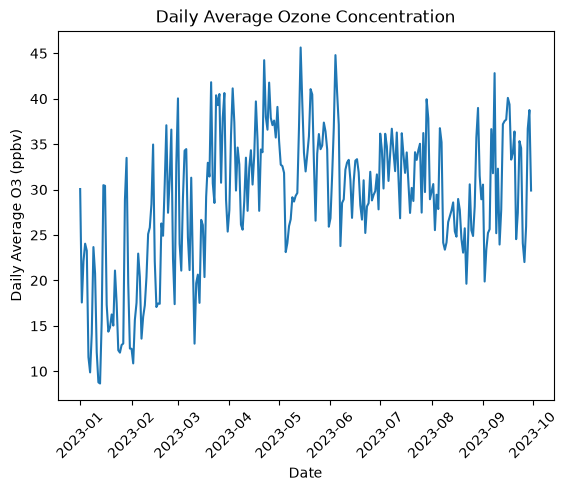

In [18]:
sns.lineplot(
    data=daily_o3,
    x="Date (Local)",
    y="O3_ppbv"
)

plt.xlabel("Date")
plt.ylabel("Daily Average O3 (ppbv)")
plt.title("Daily Average Ozone Concentration")
plt.xticks(rotation=45)

plt.show()

In [20]:
max_o3 = daily_o3.loc[daily_o3["O3_ppbv"].idxmax()]

print("Date of highest O3:", max_o3["Date (Local)"])
print("Highest O3:", max_o3["O3_ppbv"], "ppbv")

Date of highest O3: 2023-05-14 00:00:00
Highest O3: 45.6395 ppbv


In [22]:
days_above_35 = daily_o3[daily_o3["O3_ppbv"] > 35]

print("Number of days above 35 ppbv:", len(days_above_35))

Number of days above 35 ppbv: 61
